# 08. Gradient Boosting i XGBoost: drzewa, które poprawiają błędy poprzedników

Cel: pokazać naturalną kontynuację po pojedynczym drzewie i Random Forest.

Po tym notebooku student powinien rozumieć:

1. czym różni się **Random Forest** od **boostingu**,
2. dlaczego boosting buduje drzewa **sekwencyjnie**, a nie niezależnie,
3. jak użyć `GradientBoostingClassifier` ze scikit-learn,
4. jak użyć `XGBClassifier` z biblioteki XGBoost,
5. jak porównać modele na tym samym problemie churn,
6. dlaczego parametry `n_estimators`, `learning_rate` i `max_depth` są kluczowe.

Pracujemy na tym samym problemie co wcześniej: przewidywanie, czy klient odejdzie z usługi.

## 1. Od jednego drzewa do wielu drzew

Zaczynamy od porównania trzech pomysłów, które pojawiały się w kolejnych notebookach.

```text
Decision Tree
    jedno drzewo
    jedna ścieżka decyzji
    łatwa interpretacja, ale duża niestabilność

Random Forest
    wiele drzew budowanych niezależnie
    każde drzewo widzi trochę inne dane / cechy
    końcowa decyzja = głosowanie wielu drzew

Gradient Boosting / XGBoost
    wiele małych drzew budowanych po kolei
    każde kolejne drzewo poprawia błędy poprzedniego modelu
```

Najważniejsza różnica:

```text
Random Forest pyta:
    co powiedzą różne niezależne drzewa?

Boosting pyta:
    gdzie obecny model jeszcze się myli
    i jakie małe drzewo może to poprawić?
```

Można to zapamiętać tak:

```text
Random Forest = ensemble / głosowanie / redukcja wariancji

Boosting = sekwencyjne poprawki / redukcja błędu modelu
```

W praktyce końcowy model boostingowy jest sumą wielu małych poprawek.


## 2. Intuicja boostingu: poprawianie błędów krok po kroku

Wyobraźmy sobie, że mamy już prosty model, ale model myli się na części klientów.

Boosting pyta:

```text
na których przykładach obecny model ma problem?
```

Następnie dodaje kolejne małe drzewo, które próbuje poprawić te błędy.

Schematycznie:

```text
model początkowy
    ↓
sprawdź błędy
    ↓
dodaj małe drzewo-poprawkę
    ↓
sprawdź nowe błędy
    ↓
dodaj kolejne małe drzewo-poprawkę
    ↓
...
```

W Gradient Boostingu model budujemy addytywnie:

$$
F_{t+1}(x) = F_t(x) + \eta \cdot h_t(x)
$$

gdzie:

- $F_t(x)$ — aktualny model po $t$ krokach,
- $h_t(x)$ — nowe małe drzewo,
- $\eta$ — `learning_rate`, czyli siła pojedynczej poprawki.

W klasyfikacji technicznie nie dopasowujemy zwykłych reszt tak prosto jak w regresji, ale intuicja pozostaje podobna:

```text
kolejne drzewa poprawiają kierunek błędu poprzedniego modelu
```


## 3. Dane: ten sam problem churn

Używamy danych o klientach:

- `miesiace_umowy` — jak długo klient jest z firmą,
- `liczba_reklamacji` — ile miał reklamacji,
- `srednie_logowania_tyg` — średnia liczba logowań tygodniowo,
- `plan`, `umowa`, `rabat` — cechy kategoryczne,
- `odejdzie` — etykieta `tak` / `nie`.

Notebook próbuje wczytać plik `data/04_klienci_churn.csv`. Jeżeli go nie ma, tworzy mały fallback dydaktyczny, żeby notebook dało się uruchomić samodzielnie.

### Uwaga techniczna: XGBoost

Notebook działa także wtedy, gdy pakiet `xgboost` nie jest zainstalowany — wtedy część XGBoost zostanie pominięta, a idea boostingu będzie pokazana na `GradientBoostingClassifier` ze scikit-learn.

Jeśli chcesz uruchomić sekcje XGBoost, zainstaluj pakiet poza notebookiem:

```bash
pip install xgboost
```


## 4. Jak powstały dane, jeśli nie mamy pliku CSV?

Jeśli notebook nie znajdzie pliku `data/04_klienci_churn.csv`, tworzy syntetyczny zbiór churn.

To znaczy: dane są sztucznie wygenerowane, ale według kontrolowanej logiki.

Niektóre cechy zwiększają ryzyko odejścia:

- umowa miesięczna,
- dużo reklamacji,
- plan `basic`,
- krótki staż.

Inne cechy zmniejszają ryzyko odejścia:

- wysoka aktywność,
- rabat,
- dłuższa relacja z firmą.

W kodzie tworzymy ukryty `logit`, czyli ukryty wynik ryzyka odejścia. Potem zamieniamy go na prawdopodobieństwo przez funkcję sigmoidalną:

$$
p = \frac{1}{1 + e^{-logit}}
$$

Na końcu losujemy etykietę `odejdzie`, więc problem nie jest deterministyczny. Nawet klient o wysokim ryzyku może zostać, a klient o niskim ryzyku może odejść.

Dzięki temu możemy sprawdzać, czy modele ML potrafią odzyskać ukrytą strukturę problemu z danych.


In [90]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
)

# XGBoost może nie być zainstalowany w każdym środowisku.
# Jeżeli go nie ma, notebook nadal pokaże część ze sklearn.
try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("Brak pakietu xgboost. Aby uruchomić sekcje XGBoost, zainstaluj: pip install xgboost")

BASE = Path.cwd()
for candidate in [BASE, BASE.parent, Path("/mnt/data/drzewa_decyzyjne_dydaktyka")]:
    if (candidate / "data" / "04_klienci_churn.csv").exists():
        BASE = candidate
        break
else:
    BASE = Path.cwd()

csv_path = BASE / "data" / "04_klienci_churn.csv"

if csv_path.exists():
    df = pd.read_csv(csv_path)
else:
    # Fallback dydaktyczny: te same kolumny co w notebookach 05 i 06.
    rng = np.random.default_rng(42)
    n = 420

    miesiace_umowy = rng.integers(1, 61, n)
    liczba_reklamacji = rng.poisson(1.1, n)
    srednie_logowania_tyg = np.clip(rng.normal(5.0, 2.4, n), 0, 14).round(1)
    plan = rng.choice(["basic", "pro", "premium"], size=n, p=[0.45, 0.38, 0.17]).astype(object)
    umowa = rng.choice(["miesieczna", "roczna", "dwuletnia"], size=n, p=[0.55, 0.30, 0.15]).astype(object)
    rabat = rng.choice(["tak", "nie"], size=n, p=[0.35, 0.65]).astype(object)

    # Tworzymy etykietę z kontrolowanym szumem.
    # Klient częściej odchodzi, gdy ma miesięczną umowę, dużo reklamacji,
    # mało logowań i krótki staż.
    logit = (
        -0.10
        + 0.95 * (umowa == "miesieczna")
        + 0.45 * (plan == "basic")
        + 0.65 * (liczba_reklamacji >= 2)
        - 0.030 * miesiace_umowy
        - 0.18 * srednie_logowania_tyg
        - 0.30 * (rabat == "tak")
    )
    prob = 1 / (1 + np.exp(-logit))
    odejdzie = np.where(rng.random(n) < prob, "tak", "nie")

    df = pd.DataFrame({
        "klient_id": range(1, n + 1),
        "miesiace_umowy": miesiace_umowy,
        "liczba_reklamacji": liczba_reklamacji,
        "srednie_logowania_tyg": srednie_logowania_tyg,
        "plan": plan,
        "umowa": umowa,
        "rabat": rabat,
        "odejdzie": odejdzie,
    })

    # Kilka braków danych, żeby pipeline miał sens.
    df.loc[rng.choice(n, 14, replace=False), "srednie_logowania_tyg"] = np.nan
    df.loc[rng.choice(n, 10, replace=False), "plan"] = np.nan
    df.loc[rng.choice(n, 8, replace=False), "rabat"] = np.nan

df.head()

,klient_id,miesiace_umowy,liczba_reklamacji,srednie_logowania_tyg,plan,umowa,rabat,odejdzie
0,1,20,1,0.1,pro,miesieczna,nie,nie
1,2,33,2,2.2,standard,miesieczna,tak,tak
2,3,18,1,4.7,standard,roczna,nie,nie
3,4,3,1,NaN,basic,roczna,nie,tak
4,5,21,2,3.2,basic,miesieczna,nie,nie


In [91]:
print("Rozmiar danych:", df.shape)
print()
print("Braki danych:")
print(df.isna().sum())
print()
print("Rozkład klasy docelowej:")
print(df["odejdzie"].value_counts(normalize=True).rename("proporcja"))

Rozmiar danych: (126, 8)

Braki danych:
klient_id                0
miesiace_umowy           0
liczba_reklamacji        0
srednie_logowania_tyg    9
plan                     6
umowa                    0
rabat                    0
odejdzie                 0
dtype: int64

Rozkład klasy docelowej:
nie    0.690476
tak    0.309524
Name: proporcja, dtype: float64


## 5. Wspólny preprocessing

Żeby porównanie modeli było uczciwe, wszystkie modele dostają ten sam podział train/test oraz ten sam preprocessing:

- liczby: uzupełnienie braków medianą,
- kategorie: uzupełnienie najczęstszą wartością i one-hot encoding.

Dodatkowo kodujemy etykietę `odejdzie` do wartości `0/1`, bo XGBoost najwygodniej pracuje na etykietach liczbowych.

In [92]:
X = df.drop(columns=["odejdzie", "klient_id"])
y_text = df["odejdzie"]

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)

print("Mapowanie etykiet:")
for label, code_value in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(f"  {label!r} -> {code_value}")

positive_label = "tak"
positive_code = int(label_encoder.transform([positive_label])[0])
print("\nKlasa pozytywna:", positive_label, "=", positive_code)

num_cols = ["miesiace_umowy", "liczba_reklamacji", "srednie_logowania_tyg"]
cat_cols = ["plan", "umowa", "rabat"]

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("\nTrain:", X_train.shape)
print("Test: ", X_test.shape)

Mapowanie etykiet:
  'nie' -> 0
  'tak' -> 1

Klasa pozytywna: tak = 1

Train: (88, 6)
Test:  (38, 6)


### Co widzi model po preprocessingu?

Oryginalne dane klienta zawierają teksty, np. `plan`, `umowa`, `rabat`.

Po preprocessingu model nie widzi już tekstów. Widzi liczby:

- cechy liczbowe po uzupełnieniu braków,
- cechy kategoryczne zamienione przez one-hot encoding na kolumny 0/1.

To jest ważne, bo wszystkie modele w tym notebooku uczą się właśnie na tej przetworzonej reprezentacji.


In [93]:
# Ten blok pokazuje, co model faktycznie widzi po preprocessingu.
# Nie trenujemy tu jeszcze żadnego modelu — tylko dopasowujemy i stosujemy preprocessing.

prep_preview = clone(preprocess)
prep_preview.fit(X_train)

feature_names = prep_preview.get_feature_names_out()

one_client = X_train.iloc[[0]]

print("Przed preprocessingiem:")
display(one_client)

one_client_transformed = prep_preview.transform(one_client)

one_client_transformed_df = pd.DataFrame(
    one_client_transformed,
    columns=feature_names,
    index=one_client.index
)

print("Po preprocessingiu:")
display(one_client_transformed_df)


Przed preprocessingiem:


,miesiace_umowy,liczba_reklamacji,srednie_logowania_tyg,plan,umowa,rabat
97,9,0,2.7,standard,miesieczna,nie


Po preprocessingiu:


,num__miesiace_umowy,num__liczba_reklamacji,num__srednie_logowania_tyg,cat__plan_basic,cat__plan_pro,cat__plan_standard,cat__umowa_miesieczna,cat__umowa_roczna,cat__rabat_nie,cat__rabat_tak
97,9.0,0.0,2.7,0.0,0.0,1.0,1.0,0.0,1.0,0.0


## 6. Modele bazowe: baseline, drzewo i Random Forest

Zanim przejdziemy do boostingu, ustawiamy punkt odniesienia:

1. **baseline** — zawsze przewiduje najczęstszą klasę,
2. **pojedyncze drzewo** — interpretowalne, ale potencjalnie niestabilne,
3. **Random Forest** — wiele drzew głosujących razem.

Dopiero potem dokładamy modele boostingowe.

In [94]:
tree_pipe = Pipeline([
    ("prep", preprocess),
    ("model", DecisionTreeClassifier(
        max_depth=3,
        min_samples_leaf=4,
        random_state=42
    ))
])

forest_pipe = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=150,
        max_depth=6,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=1
    ))
])

tree_pipe.fit(X_train, y_train)
forest_pipe.fit(X_train, y_train)

print("Gotowe: pojedyncze drzewo i Random Forest nauczone.")

Gotowe: pojedyncze drzewo i Random Forest nauczone.


## 7. Gradient Boosting ze scikit-learn

`GradientBoostingClassifier` buduje model etapami. Każdy etap dodaje kolejne małe drzewo, które poprawia aktualny model.

W praktyce ważne parametry to:

- `n_estimators` — ile małych drzew dodajemy,
- `learning_rate` — jak mocno każde drzewo wpływa na wynik,
- `max_depth` — jak złożone są pojedyncze małe drzewa,
- `subsample` — czy każde drzewo ma widzieć cały zbiór, czy losową część danych.

W boostingu często używa się **płytkich drzew**, np. głębokości 1–3. Pojedyncze drzewko jest słabe, ale wiele takich drzewek razem może stworzyć mocny model.

In [95]:
gb_pipe = Pipeline([
    ("prep", preprocess),
    ("model", GradientBoostingClassifier(
        n_estimators=120,
        learning_rate=0.05,
        max_depth=2,
        subsample=0.90,
        random_state=42
    ))
])

gb_pipe.fit(X_train, y_train)
print("GradientBoostingClassifier nauczony.")

GradientBoostingClassifier nauczony.


## 8. XGBoost: praktyczna wersja gradient boostingu

XGBoost to popularna, zoptymalizowana biblioteka do gradient boostingu na drzewach.

Myślowo zostajemy przy tej samej idei:

```text
wiele małych drzew + kolejne drzewa poprawiają błędy poprzednich
```

XGBoost dodaje jednak kilka praktycznych mechanizmów:

1. **regularizacja**  
   Model karze zbyt złożone drzewa, żeby ograniczyć overfitting.

2. **kontrola złożoności drzewa**  
   Parametry takie jak `max_depth`, `min_child_weight`, `gamma` kontrolują, jak łatwo model tworzy nowe podziały.

3. **subsampling**  
   Model może używać tylko części obserwacji i części cech, podobnie jak w Random Forest, ale nadal uczy drzewa sekwencyjnie.

4. **learning_rate**  
   Każde drzewo dodaje tylko małą poprawkę.

5. **early stopping**  
   Możemy zatrzymać uczenie, gdy wynik na walidacji przestaje się poprawiać.

W skrócie:

```text
Gradient Boosting = sekwencyjne poprawianie błędów

XGBoost = Gradient Boosting + regularizacja + szybka implementacja + kontrola overfittingu
```

### Dlaczego używamy `scale_pos_weight`?

W problemie churn klasa `tak` jest rzadsza niż `nie`.

Model może więc preferować klasę `nie`, bo dzięki temu łatwo osiąga wysoką accuracy.

Parametr `scale_pos_weight` mówi XGBoostowi:

```text
zwróć większą uwagę na rzadszą klasę pozytywną
```

Nie gwarantuje to lepszego wyniku, ale często pomaga poprawić wykrywanie klasy `tak`.

Jeżeli pakiet nie jest dostępny w środowisku, sekcja XGBoost zostanie pominięta. Wtedy można zainstalować go poza notebookiem:

```bash
pip install xgboost
```


In [96]:
if XGB_AVAILABLE:
    n_positive = (y_train == positive_code).sum()
    n_negative = len(y_train) - n_positive
    scale_pos_weight = n_negative / n_positive

    print("scale_pos_weight:", round(scale_pos_weight, 3))

    xgb_pipe = Pipeline([
        ("prep", preprocess),
        ("model", XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            n_estimators=300,
            learning_rate=0.03,
            max_depth=2,
            subsample=0.85,
            colsample_bytree=0.85,
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            n_jobs=1,
            verbosity=0
        ))
    ])

    xgb_pipe.fit(X_train, y_train)
    print("XGBClassifier nauczony.")
else:
    xgb_pipe = None
    print("Pomijam XGBoost, bo pakiet xgboost nie jest zainstalowany.")

scale_pos_weight: 2.259
XGBClassifier nauczony.


## 9. Porównanie modeli

Porównujemy modele na tych samych danych testowych.

Używamy kilku metryk:

- `accuracy` — ogólny odsetek poprawnych predykcji,
- `precision` dla klasy `tak` — gdy model mówi „odejdzie”, jak często ma rację,
- `recall` dla klasy `tak` — ile faktycznych odejść model wykrył,
- `f1` — kompromis między precision i recall,
- `roc_auc` — jakość rankingu prawdopodobieństw.

Przy churnie samo `accuracy` może być mylące, bo często jedna klasa dominuje.

In [97]:
def evaluate_model(name, estimator, X_train, X_test, y_train, y_test):
    """Zwraca podstawowe metryki dla modelu/pipeline'u."""
    pred_train = estimator.predict(X_train)
    pred_test = estimator.predict(X_test)

    if hasattr(estimator, "predict_proba"):
        proba_test = estimator.predict_proba(X_test)[:, positive_code]
        roc_auc = roc_auc_score(y_test, proba_test)
    else:
        roc_auc = np.nan

    return {
        "model": name,
        "accuracy_train": accuracy_score(y_train, pred_train),
        "accuracy_test": accuracy_score(y_test, pred_test),
        "precision_tak": precision_score(y_test, pred_test, pos_label=positive_code, zero_division=0),
        "recall_tak": recall_score(y_test, pred_test, pos_label=positive_code, zero_division=0),
        "f1_tak": f1_score(y_test, pred_test, pos_label=positive_code, zero_division=0),
        "roc_auc": roc_auc,
    }

baseline_class = pd.Series(y_train).mode().iloc[0]
baseline_pred_test = np.full_like(y_test, fill_value=baseline_class)

rows = [{
    "model": "Baseline: najczęstsza klasa",
    "accuracy_train": np.nan,
    "accuracy_test": accuracy_score(y_test, baseline_pred_test),
    "precision_tak": precision_score(y_test, baseline_pred_test, pos_label=positive_code, zero_division=0),
    "recall_tak": recall_score(y_test, baseline_pred_test, pos_label=positive_code, zero_division=0),
    "f1_tak": f1_score(y_test, baseline_pred_test, pos_label=positive_code, zero_division=0),
    "roc_auc": np.nan,
}]

rows.append(evaluate_model("Decision Tree", tree_pipe, X_train, X_test, y_train, y_test))
rows.append(evaluate_model("Random Forest", forest_pipe, X_train, X_test, y_train, y_test))
rows.append(evaluate_model("Gradient Boosting", gb_pipe, X_train, X_test, y_train, y_test))

if XGB_AVAILABLE:
    rows.append(evaluate_model("XGBoost", xgb_pipe, X_train, X_test, y_train, y_test))

comparison = pd.DataFrame(rows)
comparison.sort_values("f1_tak", ascending=False).round(3)

,model,accuracy_train,accuracy_test,precision_tak,recall_tak,f1_tak,roc_auc
1,Decision Tree,0.864,0.816,0.778,0.583,0.667,0.851
4,XGBoost,0.966,0.763,0.600,0.750,0.667,0.875
2,Random Forest,0.920,0.816,0.857,0.500,0.632,0.856
3,Gradient Boosting,0.955,0.737,0.583,0.583,0.583,0.857
0,Baseline: najczęstsza klasa,NaN,0.684,0.000,0.000,0.000,NaN


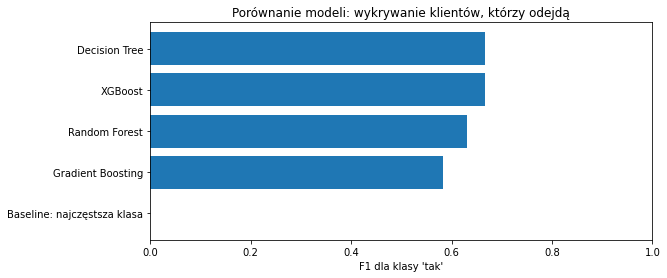

In [98]:
plot_df = comparison.sort_values("f1_tak", ascending=True)

plt.figure(figsize=(9, 4))
plt.barh(plot_df["model"], plot_df["f1_tak"])
plt.xlabel("F1 dla klasy 'tak'")
plt.title("Porównanie modeli: wykrywanie klientów, którzy odejdą")
plt.xlim(0, 1)
plt.show()

## Jak czytać wyniki?

Nie wybieramy modelu tylko po `accuracy`.

W churn szczególnie interesuje nas klasa `tak`, czyli klienci, którzy mogą odejść.

Dlatego patrzymy na:

- `recall_tak` — ilu odchodzących klientów wykrywamy,
- `precision_tak` — ilu oznaczonych jako zagrożeni naprawdę odchodzi,
- `f1_tak` — kompromis między precision i recall,
- `roc_auc` — czy model dobrze szereguje klientów według ryzyka.

Model z najlepszą accuracy nie musi być najlepszy biznesowo.

Ważny wniosek:

```text
bardziej zaawansowany model nie zawsze automatycznie wygrywa
```

Gradient Boosting i XGBoost są mocne, ale wymagają kontroli parametrów, metryk i progu decyzyjnego.


## 10. Macierz pomyłek dla modelu boostingowego

Dla churnu często najciekawsze pytanie brzmi:

> Czy model dobrze wykrywa klientów, którzy faktycznie odejdą?

Dlatego patrzymy nie tylko na accuracy, ale też na macierz pomyłek.

XGBoost
              precision    recall  f1-score   support

         nie       0.87      0.77      0.82        26
         tak       0.60      0.75      0.67        12

    accuracy                           0.76        38
   macro avg       0.73      0.76      0.74        38
weighted avg       0.78      0.76      0.77        38



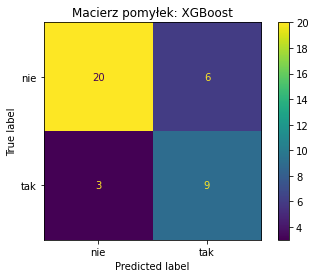

In [99]:
best_boosting_pipe = xgb_pipe if XGB_AVAILABLE else gb_pipe
best_boosting_name = "XGBoost" if XGB_AVAILABLE else "Gradient Boosting"

boost_pred = best_boosting_pipe.predict(X_test)

print(best_boosting_name)
print(classification_report(
    y_test,
    boost_pred,
    target_names=label_encoder.classes_,
    zero_division=0
))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    boost_pred,
    display_labels=label_encoder.classes_
)
plt.title(f"Macierz pomyłek: {best_boosting_name}")
plt.show()

## 11. Jak boosting poprawia się wraz z kolejnymi drzewami?

W `GradientBoostingClassifier` możemy podejrzeć wynik po kolejnych etapach uczenia.

Na początku model ma mało drzew, więc jest prosty. Potem dodajemy kolejne drzewa i sprawdzamy, czy jakość na treningu oraz teście rośnie.

To jest dobry sposób na zobaczenie, że boosting buduje model stopniowo.

In [100]:
# Pipeline nie ma metody staged_predict, dlatego bierzemy przetworzone dane
# i sam model ze środka pipeline'u.
X_train_t = gb_pipe.named_steps["prep"].transform(X_train)
X_test_t = gb_pipe.named_steps["prep"].transform(X_test)
gb_model = gb_pipe.named_steps["model"]

stage_rows = []
for i, (pred_train_stage, pred_test_stage) in enumerate(
    zip(gb_model.staged_predict(X_train_t), gb_model.staged_predict(X_test_t)),
    start=1
):
    stage_rows.append({
        "n_drzewek": i,
        "accuracy_train": accuracy_score(y_train, pred_train_stage),
        "accuracy_test": accuracy_score(y_test, pred_test_stage),
    })

stages = pd.DataFrame(stage_rows)
stages.tail()

,n_drzewek,accuracy_train,accuracy_test
115,116,0.954545,0.736842
116,117,0.954545,0.736842
117,118,0.954545,0.736842
118,119,0.954545,0.736842
119,120,0.954545,0.736842


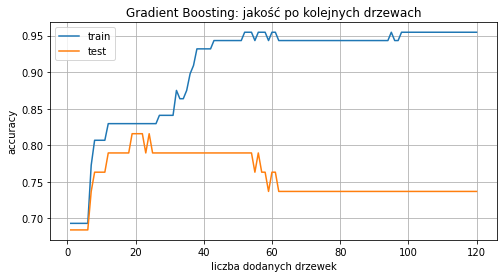

In [101]:
plt.figure(figsize=(8, 4))
plt.plot(stages["n_drzewek"], stages["accuracy_train"], label="train")
plt.plot(stages["n_drzewek"], stages["accuracy_test"], label="test")
plt.xlabel("liczba dodanych drzewek")
plt.ylabel("accuracy")
plt.title("Gradient Boosting: jakość po kolejnych drzewach")
plt.legend()
plt.grid(True)
plt.show()

## 12. `learning_rate` i `n_estimators`

W boostingu mamy ważny kompromis:

```text
większy learning_rate  -> każde drzewo robi większy krok
mniejszy learning_rate -> każde drzewo robi mniejszy krok, ale zwykle potrzeba więcej drzew
```

Często dobre modele boostingowe mają wiele małych drzew i umiarkowanie mały `learning_rate`.

In [102]:
settings = [
    {"learning_rate": 0.20, "n_estimators": 40},
    {"learning_rate": 0.10, "n_estimators": 80},
    {"learning_rate": 0.05, "n_estimators": 160},
    {"learning_rate": 0.02, "n_estimators": 300},
]

lr_rows = []
for params in settings:
    pipe = Pipeline([
        ("prep", preprocess),
        ("model", GradientBoostingClassifier(
            learning_rate=params["learning_rate"],
            n_estimators=params["n_estimators"],
            max_depth=2,
            subsample=0.90,
            random_state=42
        ))
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, positive_code]
    lr_rows.append({
        **params,
        "accuracy_test": accuracy_score(y_test, pred),
        "f1_tak": f1_score(y_test, pred, pos_label=positive_code, zero_division=0),
        "roc_auc": roc_auc_score(y_test, proba),
    })

pd.DataFrame(lr_rows).round(3)

,learning_rate,n_estimators,accuracy_test,f1_tak,roc_auc
0,0.20,40,0.763,0.609,0.848
1,0.10,80,0.789,0.667,0.859
2,0.05,160,0.789,0.667,0.853
3,0.02,300,0.763,0.640,0.854


## 13. Ważność cech w modelach boostingowych

Podobnie jak w drzewach i Random Forest, modele boostingowe mają `feature_importances_`.

Interpretacja jest podobna:

> ważność cechy mówi, jak bardzo dana cecha pomagała modelowi w budowaniu dobrych splitów.

To nadal nie oznacza związku przyczynowego. To jest informacja o tym konkretnym modelu i konkretnych danych.

In [103]:
feature_names = best_boosting_pipe.named_steps["prep"].get_feature_names_out()
boost_model = best_boosting_pipe.named_steps["model"]

importance = pd.DataFrame({
    "cecha_po_transformacji": feature_names,
    "importance": boost_model.feature_importances_
}).sort_values("importance", ascending=False)

importance.head(10)

,cecha_po_transformacji,importance
1,num__liczba_reklamacji,0.226797
4,cat__plan_pro,0.186398
2,num__srednie_logowania_tyg,0.118389
0,num__miesiace_umowy,0.111488
6,cat__umowa_miesieczna,0.110571
7,cat__umowa_roczna,0.068062
3,cat__plan_basic,0.055475
8,cat__rabat_nie,0.052542
9,cat__rabat_tak,0.051525
5,cat__plan_standard,0.018753


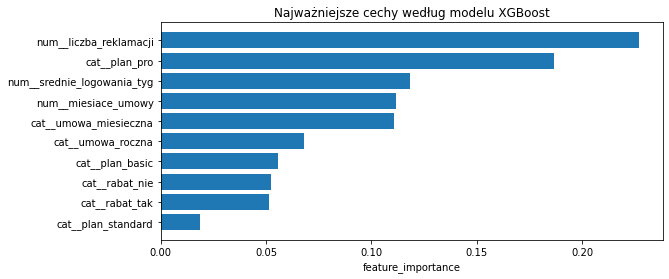

In [104]:
top = importance.head(10).iloc[::-1]

plt.figure(figsize=(9, 4))
plt.barh(top["cecha_po_transformacji"], top["importance"])
plt.xlabel("feature_importance")
plt.title(f"Najważniejsze cechy według modelu {best_boosting_name}")
plt.show()

## 14. Predykcja jako ranking ryzyka

W churnie często nie chodzi tylko o odpowiedź `tak` / `nie`.

Często chcemy ranking:

> którzy klienci mają największe ryzyko odejścia?

Do tego używamy `predict_proba()` i sortujemy klientów po prawdopodobieństwie klasy `tak`.

In [105]:
risk = X_test.copy()
risk["prawdziwa_etykieta"] = label_encoder.inverse_transform(y_test)
risk["p_odejdzie_tak"] = best_boosting_pipe.predict_proba(X_test)[:, positive_code]
risk["predykcja"] = label_encoder.inverse_transform(best_boosting_pipe.predict(X_test))

risk.sort_values("p_odejdzie_tak", ascending=False).head(10)

,miesiace_umowy,liczba_reklamacji,srednie_logowania_tyg,plan,umowa,rabat,prawdziwa_etykieta,p_odejdzie_tak,predykcja
27,8,3,1.9,standard,miesieczna,nie,tak,0.986891,tak
34,1,2,2.2,basic,miesieczna,nie,tak,0.973042,tak
35,11,3,3.0,standard,miesieczna,tak,tak,0.972338,tak
31,4,2,NaN,basic,miesieczna,nie,tak,0.969028,tak
65,12,3,4.4,basic,miesieczna,nie,tak,0.947370,tak
87,2,1,3.0,standard,miesieczna,nie,nie,0.881735,tak
46,2,1,2.1,standard,miesieczna,nie,tak,0.879938,tak
4,21,2,3.2,basic,miesieczna,nie,nie,0.777057,tak
1,33,2,2.2,standard,miesieczna,tak,tak,0.741415,tak
88,11,1,0.6,pro,miesieczna,nie,nie,0.699811,tak


## 15. Próg decyzyjny nie musi wynosić 0.5

`predict()` zwykle zamienia prawdopodobieństwo na klasę przy progu około `0.5`.

W churnie czasem bardziej zależy nam na wykrywaniu klientów zagrożonych odejściem, nawet kosztem większej liczby fałszywych alarmów. Wtedy możemy zmienić próg decyzyjny.

Przykład:

```text
p_odejdzie_tak >= 0.50 -> przewiduj tak
p_odejdzie_tak >= 0.35 -> przewiduj tak bardziej agresywnie
```

Niższy próg zwykle zwiększa `recall`, ale może zmniejszyć `precision`.

In [106]:
proba_test = best_boosting_pipe.predict_proba(X_test)[:, positive_code]

threshold_rows = []
for threshold in np.linspace(0.20, 0.80, 13):
    pred_threshold = (proba_test >= threshold).astype(int)
    threshold_rows.append({
        "threshold": threshold,
        "precision_tak": precision_score(y_test, pred_threshold, pos_label=positive_code, zero_division=0),
        "recall_tak": recall_score(y_test, pred_threshold, pos_label=positive_code, zero_division=0),
        "f1_tak": f1_score(y_test, pred_threshold, pos_label=positive_code, zero_division=0),
    })

thresholds = pd.DataFrame(threshold_rows)
thresholds.sort_values("f1_tak", ascending=False).round(3).head(8)

,threshold,precision_tak,recall_tak,f1_tak
1,0.25,0.550,0.917,0.687
2,0.30,0.550,0.917,0.687
0,0.20,0.522,1.000,0.686
3,0.35,0.556,0.833,0.667
8,0.60,0.667,0.667,0.667
9,0.65,0.667,0.667,0.667
10,0.70,0.778,0.583,0.667
6,0.50,0.600,0.750,0.667


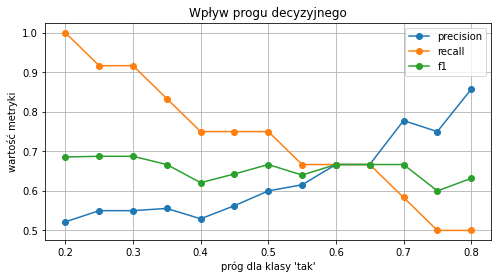

In [107]:
plt.figure(figsize=(8, 4))
plt.plot(thresholds["threshold"], thresholds["precision_tak"], marker="o", label="precision")
plt.plot(thresholds["threshold"], thresholds["recall_tak"], marker="o", label="recall")
plt.plot(thresholds["threshold"], thresholds["f1_tak"], marker="o", label="f1")
plt.xlabel("próg dla klasy 'tak'")
plt.ylabel("wartość metryki")
plt.title("Wpływ progu decyzyjnego")
plt.legend()
plt.grid(True)
plt.show()

## 16. Opcjonalnie: early stopping w XGBoost

Jeżeli ustawimy bardzo dużą liczbę drzew, model może zacząć przeuczać się na treningu.

`early_stopping_rounds` pozwala zatrzymać trening, gdy wynik na zbiorze walidacyjnym przestaje się poprawiać.

Ważne: zbiór walidacyjny powinien pochodzić tylko z części treningowej. Nie używamy testu do sterowania treningiem.

In [108]:
if XGB_AVAILABLE:
    X_fit, X_valid, y_fit, y_valid = train_test_split(
        X_train, y_train, test_size=0.25, random_state=42, stratify=y_train
    )

    prep_es = clone(preprocess)
    X_fit_t = prep_es.fit_transform(X_fit)
    X_valid_t = prep_es.transform(X_valid)
    X_test_t_es = prep_es.transform(X_test)

    xgb_es = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=600,
        learning_rate=0.03,
        max_depth=2,
        subsample=0.85,
        colsample_bytree=0.85,
        scale_pos_weight=scale_pos_weight,
        early_stopping_rounds=25,
        random_state=42,
        n_jobs=1,
        verbosity=0
    )

    xgb_es.fit(
        X_fit_t,
        y_fit,
        eval_set=[(X_valid_t, y_valid)],
        verbose=False
    )

    pred_es = xgb_es.predict(X_test_t_es)
    proba_es = xgb_es.predict_proba(X_test_t_es)[:, positive_code]

    print("Najlepsza iteracja:", xgb_es.best_iteration)
    print("Accuracy test:", round(accuracy_score(y_test, pred_es), 3))
    print("F1 dla klasy 'tak':", round(f1_score(y_test, pred_es, pos_label=positive_code, zero_division=0), 3))
    print("ROC AUC:", round(roc_auc_score(y_test, proba_es), 3))
else:
    print("Sekcja pominięta, bo xgboost nie jest zainstalowany.")

Najlepsza iteracja: 161
Accuracy test: 0.763
F1 dla klasy 'tak': 0.64
ROC AUC: 0.867


## 17. Podsumowanie

Najważniejsza historia tego notebooka:

```text
Decision Tree
    jedno drzewo, łatwe do interpretacji

Random Forest
    wiele niezależnych drzew
    głosowanie
    większa stabilność

Gradient Boosting
    wiele małych drzew budowanych po kolei
    każde kolejne drzewo poprawia błędy poprzednich

XGBoost
    Gradient Boosting + regularizacja + kontrola złożoności + szybka implementacja
```

Najważniejsza różnica:

```text
Random Forest:
    co powiedzą różne niezależne drzewa?

Boosting:
    gdzie obecny model jeszcze się myli
    i jaką małą poprawkę dodać?
```

W problemie churn szczególnie ważne jest to,
że model ma nie tylko dobrze przewidywać większościową klasę `nie`,
ale też wykrywać klientów zagrożonych odejściem.

Dlatego analizujemy nie tylko accuracy, ale też:

- precision dla `tak`,
- recall dla `tak`,
- F1 dla `tak`,
- ROC AUC,
- ranking ryzyka,
- próg decyzyjny.

Najważniejsze parametry w boostingu:

| Parametr | Intuicja |
|---|---|
| `n_estimators` | liczba drzew / kroków boostingu |
| `learning_rate` | siła pojedynczego kroku |
| `max_depth` | złożoność pojedynczego drzewa |
| `subsample` | ile obserwacji widzi pojedynczy krok |
| `colsample_bytree` | ile cech widzi pojedyncze drzewo w XGBoost |
| `scale_pos_weight` | większa uwaga na rzadszą klasę pozytywną |
| `early_stopping_rounds` | zatrzymanie, gdy walidacja przestaje się poprawiać |

## Ćwiczenia dla studentów

1. Zmień `learning_rate` i `n_estimators`. Sprawdź, czy mniejszy krok i więcej drzew daje lepszy wynik.
2. Zmień `max_depth` w `GradientBoostingClassifier` na `1`, `2`, `4`. Czy głębsze drzewa zawsze są lepsze?
3. Porównaj `Random Forest` i `Gradient Boosting`: który model ma lepsze `recall_tak`, a który lepsze `precision_tak`?
4. Posortuj klientów po `p_odejdzie_tak`. Wybierz 5 klientów o najwyższym ryzyku i opisz, co ich łączy.
5. Zmień próg decyzyjny na `0.25`, `0.35`, `0.50`. Kiedy lepiej wybrać niższy próg?
